# Quiz 6

BEFORE YOU START THIS QUIZ:

1. Click on "Copy to Drive" to make a copy of the quiz,

2. Click on "Share",
    
3. Click on "Change" and select "Anyone with this link can edit"
    
4. Click "Copy link" and

5. Paste the link into [this Canvas assignment](https://canvas.olin.edu/courses/390/assignments/6317).

DO THIS BEFORE YOU START THE QUIZ.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Happiness

Recently I read [Happiness and Life Satisfaction](https://ourworldindata.org/happiness-and-life-satisfaction)
by Esteban Ortiz-Ospina and Max Roser, which discusses (among many other things) the relationship between income and happiness, both between countries, within countries, and over time.

It cites the [World Happiness Report](https://worldhappiness.report/), which I skimmed looking for examples of multiple regression and sources of data.

Their [Table 2.1](https://worldhappiness.report/ed/2020/social-environments-for-world-happiness/) reports the result of a multiple regression analysis that explores the relationship between happiness and six potentially predictive factors:

**Logarithm base 10 of GDP:**
"GDP per capita is in terms of Purchasing
Power Parity (PPP) adjusted to constant
2011 international dollars, taken from
the World Development Indicators
(WDI) released by the World Bank in
September 2017."

**Social support:**
"The national average
of the binary responses (either 0 or 1)
to the Gallup World Poll (GWP)
question “If you were in trouble, do
you have relatives or friends you can
count on to help you whenever you
need them, or not?”"

**Healthy life expectancy:**
"The time series of healthy life expectancy
at birth are constructed based on data
from the World Health Organization
(WHO) and WDI. WHO publishes the
data on healthy life expectancy for
the year 2012. The time series of life
expectancies, with no adjustment for
health, are available in WDI. We adopt
the following strategy to construct the
time series of healthy life expectancy
at birth: first we generate the ratios
of healthy life expectancy to life
expectancy in 2012 for countries
with both data. We then apply the
country-specific ratios to other years
to generate the healthy life expectancy
data."

**Freedom to make life choices:**
"The
national average of binary responses to
the GWP question “Are you satisfied or
dissatisfied with your freedom to
choose what you do with your life?”"

**Generosity:**
"The residual of regressing
the national average of GWP responses
to the question “Have you donated
money to a charity in the past month?”
on GDP per capita."

**Perceptions of corruption:**
"The average
of binary answers to two GWP questions:
“Is corruption widespread throughout the
government or not?” and “Is corruption
widespread within businesses or not?”
Where data for government corruption
are missing, the perception of business
corruption is used as the overall
corruption-perception measure."

The dependent variable, happiness, is the national average of responses to the "Cantril ladder question" used by the [Gallup World Poll](https://news.gallup.com/poll/122453/understanding-gallup-uses-cantril-scale.aspx):

> Please imagine a ladder with steps numbered from zero at the bottom to 10 at the top.
The top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you.
On which step of the ladder would you say you personally feel you stand at this time?  

The data used to make this table can be [downloaded from here](https://happiness-report.s3.amazonaws.com/2020/WHR20_DataForFigure2.1.xls).

In [3]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://happiness-report.s3.amazonaws.com/2020/WHR20_DataForFigure2.1.xls")

Now we can read the data into a Pandas `DataFrame`.

In [4]:
import sys

if "google.colab" in sys.modules:
    !pip install -U xlrd

In [5]:
whr = pd.read_excel("WHR20_DataForFigure2.1.xls")
whr.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.8087,0.031156,7.869766,7.747634,10.639267,0.954330,71.900826,0.949172,-0.059482,0.195445,1.972317,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857,2.762835
1,Denmark,Western Europe,7.6456,0.033492,7.711245,7.579955,10.774001,0.955991,72.402504,0.951444,0.066202,0.168489,1.972317,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260,2.432741
2,Switzerland,Western Europe,7.5599,0.035014,7.628528,7.491272,10.979933,0.942847,74.102448,0.921337,0.105911,0.303728,1.972317,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946,2.350267
3,Iceland,Western Europe,7.5045,0.059616,7.621347,7.387653,10.772559,0.974670,73.000000,0.948892,0.246944,0.711710,1.972317,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541,2.460688
4,Norway,Western Europe,7.4880,0.034837,7.556281,7.419719,11.087804,0.952487,73.200783,0.955750,0.134533,0.263218,1.972317,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101,2.168266


## Correlations

Before we go on, I'm going to make a new dataframe that contains only the columns we need, and I'm going to give them shorter names.

In [6]:
subset = pd.DataFrame()

subset["ladder"] = whr["Ladder score"]
subset["log_gdp"] = whr["Logged GDP per capita"]
subset["social"] = whr["Social support"]
subset["life_exp"] = whr["Healthy life expectancy"]
subset["freedom"] = whr["Freedom to make life choices"]
subset["generosity"] = whr["Generosity"]
subset["corruption"] = whr["Perceptions of corruption"]

Here's what the correlations look like among these variables.

In [7]:
subset.corr()

,ladder,log_gdp,social,life_exp,freedom,generosity,corruption
ladder,1.000000,0.775374,0.765001,0.770316,0.590597,0.069043,-0.418305
log_gdp,0.775374,1.000000,0.781814,0.848469,0.419019,-0.118399,-0.334729
social,0.765001,0.781814,1.000000,0.742744,0.478863,-0.056780,-0.210530
life_exp,0.770316,0.848469,0.742744,1.000000,0.448846,-0.071852,-0.353841
freedom,0.590597,0.419019,0.478863,0.448846,1.000000,0.253721,-0.420145
generosity,0.069043,-0.118399,-0.056780,-0.071852,0.253721,1.000000,-0.278480
corruption,-0.418305,-0.334729,-0.210530,-0.353841,-0.420145,-0.278480,1.000000


**Question 1:** Use the Seaborn function `pairplot` to generate distributions and scatterplots for the columns in `subset`. Do you see any scatterplots that might indicate a non-linear relationship?

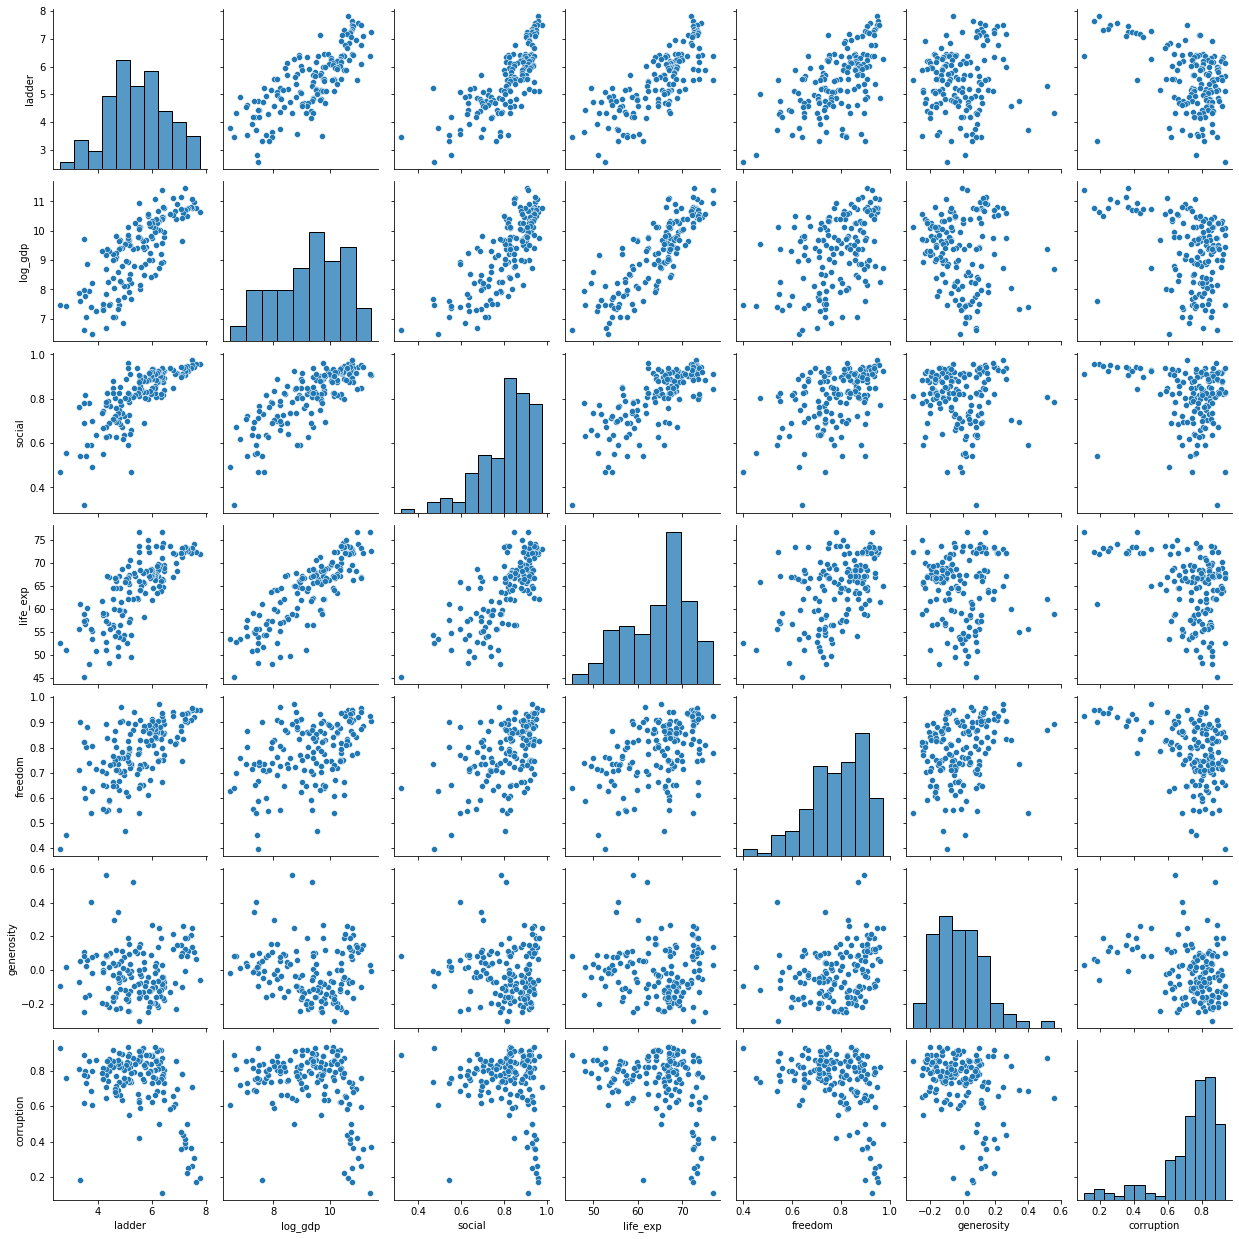

In [8]:
# Solution

sns.pairplot(subset)
None

In [9]:
# Solution

# Some are an odd shape, but I don't see anything clearly nonlinear.

**Question 2:** Use `linregress` from `scipy.stats` to compute a simple regression of `ladder` as a function of `log_gdp`. 

In [10]:
# Solution

from scipy.stats import linregress

res = linregress(subset["log_gdp"], subset["ladder"])
res

LinregressResult(slope=0.717738495630452, intercept=-1.1986460618088843, rvalue=0.7753744007429199, pvalue=5.983050807797873e-32, stderr=0.047570849726545426, intercept_stderr=0.44585973641760784)

**Question 3:** Write a sentence or two that interpret the estimated slope. For example, if we are comparing two countries with different GDPs, what difference would we expect in their average happiness?

In [11]:
# Solution

# Expected answer: If the log GDP in one country exceeds the log GDP in another country
# by one unit, we would expect the average ladder score to be higher by about 0.7

# Possible answer: If the GDP in one country exceeds the GDP in another country
# by a FACTOR of 2.7, we would expect the average ladder score to be higher by about 0.7

**Question 4:** Use `ols` from `statsmodels` to compute a simple regression of `ladder` as a function of `log_gdp`. Confirm that the estimated slope and intercept are the same as what we got from `linregress`.

In [12]:
# Here's the import statement for `statsmodels`

import statsmodels.formula.api as smf

In [13]:
# Solution

formula = "ladder ~ log_gdp"

results = smf.ols(formula, data=subset).fit()
results.params

Intercept   -1.198646
log_gdp      0.717738
dtype: float64

**Question 5:** Using the results from the previous question and the range of `xs` from the following cell, compute the corresponding `ys` for the line of best fit.
Plot this line along with a scatter plot of `ladder` vs `log_gdp`.
The line should pass through the visual center of the scatter plot.

In [14]:
low, high = subset["log_gdp"].min(), subset["log_gdp"].max()
xs = np.linspace(low, high)

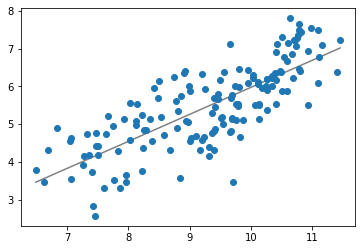

In [15]:
# Solution

intercept, slope = results.params["Intercept"], results.params["log_gdp"]
ys = slope * xs + intercept
plt.plot(xs, ys, color="gray")
plt.plot(subset["log_gdp"], subset["ladder"], "o")

**Question 6:** Let's see what the relationship is between `corruption` and `ladder` while controlling for GDP. 

Use `ols` to compute a multiple regression with `ladder` as the dependent variable and both `corruption` and `log_gdp` as predictors. Display the estimated parameters.

In [16]:
# Solution

formula = "ladder ~ log_gdp + corruption"

results = smf.ols(formula, data=subset).fit()
results.params

Intercept     0.148641
log_gdp       0.662338
corruption   -1.135290
dtype: float64

**Question 7:** Based on the scatter plot, it looks like the relationship between `corruption` and `ladder` might be nonlinear. To explore this possibility, add a new column to `subset` that contains the square of the values from `corruption`.
Then run a multiple regression with `ladder` as the dependent variable and with `log_gdp`, `corruption`, and your new variable as predictors.

In [17]:
# Solution

subset["corruption2"] = subset["corruption"] ** 2

formula = "ladder ~ log_gdp + corruption + corruption2"

results = smf.ols(formula, data=subset).fit()
results.params

Intercept      0.064532
log_gdp        0.663449
corruption    -0.845409
corruption2   -0.244268
dtype: float64

**Question 8:** To visualize the results from the previous model, let's generate some predictions.

Make a new `DataFrame` named `pred` that represents hypothetical countries with different perceived levels of corruption.

In [18]:
# Solution

pred = pd.DataFrame()

Now add a column named `corruption` that contains an array of values between `low` and `high`, as computed in the next cell.
Then add a column that contains the square of these corruption values. Finally, add a column that sets `log_gdp` to `9.0`, which is near the average across countries.

In [19]:
low, high = subset["corruption"].min(), subset["corruption"].max()

In [20]:
# Solution

pred["corruption"] = np.linspace(low, high, 20)
pred["corruption2"] = pred["corruption"] ** 2
pred["log_gdp"] = 9.0

Run the following cell `DataFrame` and the results from the previous regression to generate predictions for the hypothetical countries.

In [21]:
pred["ladder"] = results.predict(pred)

If everything so far has worked, you should be able to use the following cell to plot the predictions from the model along with a scatter plot of `ladder` vs `corruption`.

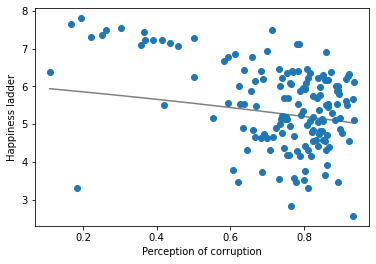

In [22]:
plt.plot(pred["corruption"], pred["ladder"], color="gray")
plt.plot(subset["corruption"], subset["ladder"], "o")

plt.xlabel("Perception of corruption")
plt.ylabel("Happiness ladder")
None

## Standardizing

The following cell runs a "kitchen sink model" with all of the predictors (but not the square of corruption).

In [23]:
formula = "ladder ~ log_gdp + social + life_exp + freedom + generosity + corruption"

results = smf.ols(formula, data=subset).fit()
results.params

Intercept    -2.059377
log_gdp       0.229079
social        2.723318
life_exp      0.035307
freedom       1.776815
generosity    0.410566
corruption   -0.628162
dtype: float64

It is tempting to compare the estimated parameters to see which ones have the strongest relationship with `ladder`, but that would be misleading because the various predictors are in different units with different ranges of values.
To demonstrate that point, here are their standard deviations. Some are clearly bigger than others.

In [24]:
subset.std()

ladder         1.112270
log_gdp        1.201588
social         0.121453
life_exp       7.057848
freedom        0.117786
generosity     0.151809
corruption     0.175172
corruption2    0.209841
dtype: float64

A solution to this problem is to "standardize" the dependent variable and the predictors so that they all have mean 0 and standard deviation 1.
Here's how we can standardize the columns in subset.

In [25]:
standardized = (subset - subset.mean()) / subset.std()

The following cell confirms that the means are near 0.

In [26]:
standardized.mean()

ladder        -4.934325e-16
log_gdp        7.923945e-16
social        -5.253604e-16
life_exp      -5.688986e-16
freedom       -3.628180e-16
generosity    -3.337925e-17
corruption    -1.407734e-16
corruption2    3.928593e-15
dtype: float64

And the standard deviations are near 1.

In [27]:
standardized.std()

ladder         1.0
log_gdp        1.0
social         1.0
life_exp       1.0
freedom        1.0
generosity     1.0
corruption     1.0
corruption2    1.0
dtype: float64

**Question 9:** Run the "kitchen sink" regression again using the standardized data and display the parameters.
You can interpret the parameters to mean "if two countries are the same except that one of their predictors differs by one standard deviation, we expect a corresponding increase of X standard deviations in the dependent variable", where X is the estimated parameter.


In [28]:
# Solution

formula = "ladder ~ log_gdp + social + life_exp + freedom + generosity + corruption"

results = smf.ols(formula, data=standardized).fit()
results.params

Intercept    -3.105155e-16
log_gdp       2.474749e-01
social        2.973701e-01
life_exp      2.240379e-01
freedom       1.881597e-01
generosity    5.603632e-02
corruption   -9.892975e-02
dtype: float64

**Question 10:** Based on these results, which factor has the strongest relationship with happiness? Which has the weakest?

In [29]:
# Solution

# Social is the strongest at 0.29,
# Generosity is the weakest, at 0.06.

results.params['social'], results.params['generosity']

(0.29737008343630694, 0.05603631617826252)

*Elements of Data Science*

Copyright 2022 Allen Downey

License: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)